## Introduction to the ISSA Dataset

The International Skin Spectra Archive (ISSA) offers a detailed collection of spectral and colorimetric data for human skin, encompassing 15,256 records from 2,113 subjects. This data spans from 2012 to 2024 and originates from eleven datasets curated by international laboratories across eight countries: the UK, Spain, China, Japan, Pakistan, Thailand, Iraq, and Saudi Arabia. Each dataset follows a standardised measurement protocol to maintain data consistency.

In the ISSA dataset, individual records provide extensive details including record number, data origin, subject identification, and skin type—categorised by ethnicity, gender, age, and body location. The dataset also includes detailed information on the measurement instruments used, such as type, specular component inclusion, wavelength range and interval.

Alongside spectral data, each sample also contains CIE colorimetric data, including tristimulus values, xy chromaticity coordinates, CIELAB parameters, etc., based on the CIE 1931 standard colorimetric observer and the CIE standard illuminant D65.

### Data Records

The datasheet arranges data across columns labelled A to BQ:

-   A: Unique record identifier
-   B: Data origin
-   C: Subject number
-   D to G: Ethnicity, gender, age group, and body location
-   H to L: Instrument details including type and spectral measurement specifics
-   N to BD: Spectral data from 360 nm to 780 nm
-   BF to BQ: CIE colorimetric data

### Skin Type

-   **Ethnicity**: CA (Caucasian), CN (Chinese), SA (South Asian), AF (African), IQ (Iraqi), TH (Thai), JP (Japanese), AB (Arabian)
+ **Gender**: F (Female), M (Male)
+ **Body Location**: 1 (Back of Hand), 2 (Cheek), 3 (Cheek bone), 4 (Chin), 5 (Ear Lobe), 6 (Forehead), 7 (Inner arm), 8 (Neck), 9 (Nose tip), 10 (Outer arm), 11 (Palm), 12 (Ring finger)


## Visualization of ISSA Reflectance and Its First Derivative

### ISSA Overview

Melanin index is a quantity that measures the amount of melanin present in the epidermis, calculated as
$$\mathrm{MI} = 100 \log_{10}\!\left(\frac{100}{R_{680}}\right),$$
where $R_{680}$ is reflectance at 680 nm, expressed in percent.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# set random seed for reproducibility
np.random.seed(123)

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load data
# Get the data directory located one level up from the current working directory
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')

# Load the real issa spectra data from CSV files
issa_data = pd.read_excel(os.path.join(data_dir, 'ISSA_17_Jan_2025_Yan_Lu.xlsx'), sheet_name='ISSA')
site_names = {1: 'Back of Hand', 2: 'Cheek', 3: 'Cheek Bone', 4: 'Chin', 5: 'Ear lobe', 6: 'Forehead', 
              7: 'Inner arm', 8: 'Neck', 9: 'Nose tip', 10: 'Outer arm', 11: 'Palm', 12: 'Ring finger'}
issa_wavelengths = issa_data.iloc[10, 17:48].values.astype(float)
issa_sites = issa_data.iloc[11:, 6].values.astype(int)
issa_spectra = issa_data.iloc[11:, 17:48].to_numpy()

# calculate the first derivative of the spectra
from scipy.signal import savgol_filter
issa_drv = savgol_filter(issa_spectra, window_length=5, polyorder=3, axis=1, deriv=1) / np.gradient(issa_wavelengths)  # First derivative with respect to wavelength

# remove outliers based on the first derivative
issa_drv_mean = np.mean(issa_drv, axis=0)
issa_drv_std = np.std(issa_drv, axis=0)
outlier_mask = np.any(np.abs(issa_drv - issa_drv_mean) > 5 * issa_drv_std, axis=1)
issa_spectra_clean = issa_spectra[~outlier_mask, :]
issa_sites_clean = issa_sites[~outlier_mask]
issa_drv_clean = issa_drv[~outlier_mask, :]

# Calculate the melanin and erythema index
issa_mi = 100 * np.log10(100 / issa_spectra_clean[:, 28]) # 680 nm
# issa_red = (issa_spectra_clean[:, 14] + issa_spectra_clean[:, 16] + issa_spectra_clean[:, 18]) / 3  # Average of 540 nm, 560 nm, and 580 nm
issa_ei = 100 * np.log10(issa_spectra_clean[:, 28] / issa_spectra_clean[:, 16]) # 680 nm / 560 nm

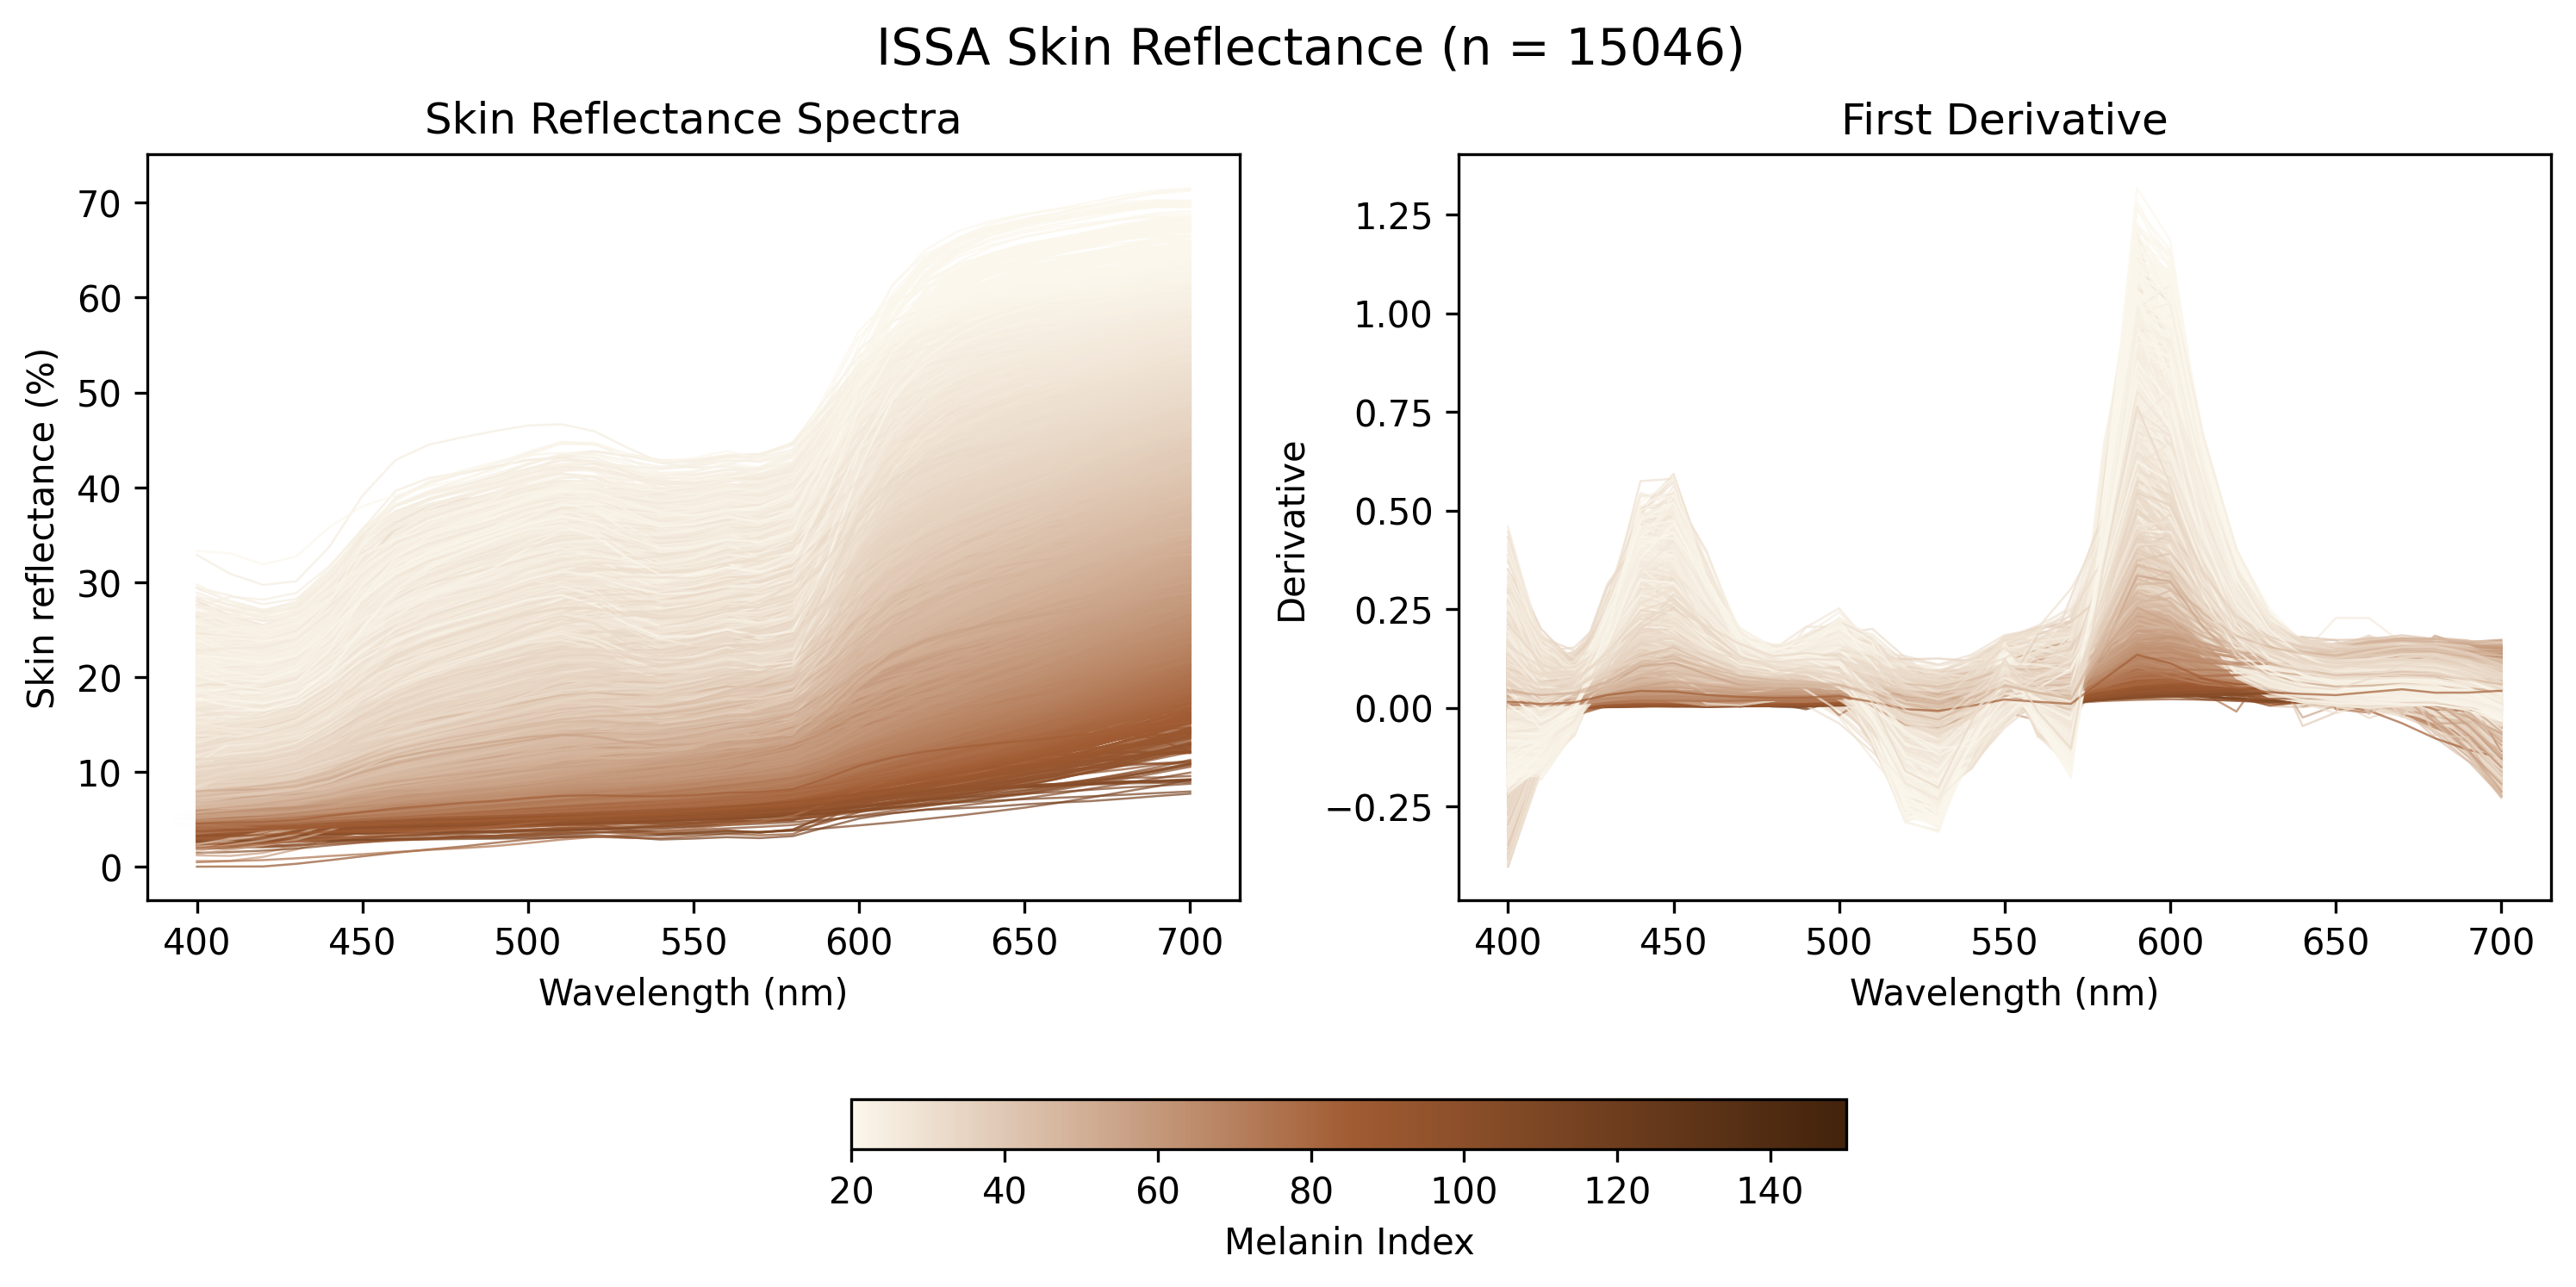

In [6]:
# Visualize the skin reflectance spectra and melanin vs erythema index side by side
fitzpatrick = ["#fbf7ec", "#a15c33", "#42230c"]
cmap = LinearSegmentedColormap.from_list("fitzpatrick", fitzpatrick)
norm = plt.Normalize(vmin=20, vmax=150)
issa_mi_clipped = np.clip(issa_mi, 20, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Plot ISSA spectra
ax = axes[0]
for i in range(issa_spectra_clean.shape[0]):
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_spectra_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('Skin Reflectance Spectra')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Skin reflectance (%)')

# Plot ISSA derivative
ax = axes[1]
for i in range(issa_drv_clean.shape[0]):
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_drv_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('First Derivative')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Derivative')

# -------- Colorbar --------
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,     # thickness
    pad=0.2            # distance from plots
)
cbar.set_label("Melanin Index")

# ---- Common title ----
fig.suptitle(f'ISSA Skin Reflectance (n = {issa_spectra_clean.shape[0]})', fontsize=14)
# plt.tight_layout()
plt.show()

### Eumelanin Human Skin Colour Scale

The Eumelanin Human Skin Colour Scale uses the following 5-point melanin index classes:

- Eumelanin Low (EML): MI < 25
- Eumelanin Intermediate Low (EMIL): 25 $\leq$ MI < 50
- Eumelanin Intermediate (EMI): 50 $\leq$ MI < 75
- Eumelanin Intermediate High (EMIH): 75 $\leq$ MI < 100
- Eumelanin High (EH): 100 $\leq$ MI

The ISSA eumelanin class information is summarized as:

In [7]:
# Set up the exact boundaries for the Eumelanin classes
# We use right=False in pd.cut so the bins are [lower, upper)
em_bins = [-np.inf, 25, 50, 75, 100, np.inf]
em_labels = ['EML (<25)', 'EMIL (25-49)', 'EMI (50-74)', 'EMIH (75-99)', 'EMH (>=100)']

issa_df = pd.DataFrame({
    'Site_ID': issa_sites_clean,
    'Site': [site_names[site] for site in issa_sites_clean],
    'MI': issa_mi,
    'EI': issa_ei
})

# Sort the MI values into their new categories
issa_df['Eumelanin Class'] = pd.cut(issa_df['MI'], bins=em_bins, labels=em_labels, right=False)

# Build the final frequency table
issa_summary_table = pd.crosstab(issa_df['Site'], issa_df['Eumelanin Class'])
issa_summary_table.loc['Total'] = issa_summary_table.sum()

# Display the result
issa_summary_table

Eumelanin Class,EML (<25),EMIL (25-49),EMI (50-74),EMIH (75-99),EMH (>=100)
Site,,,,,
Back of Hand,43,1470,160,32,1
Cheek,216,1974,227,50,4
Cheek Bone,24,186,18,0,0
Chin,271,1499,211,36,5
Ear lobe,9,395,57,12,3
Forehead,77,1756,190,30,3
Inner arm,44,1584,50,0,0
Neck,51,888,167,53,0
Nose tip,29,582,31,1,0


### Visualization by Eumelanin Classes

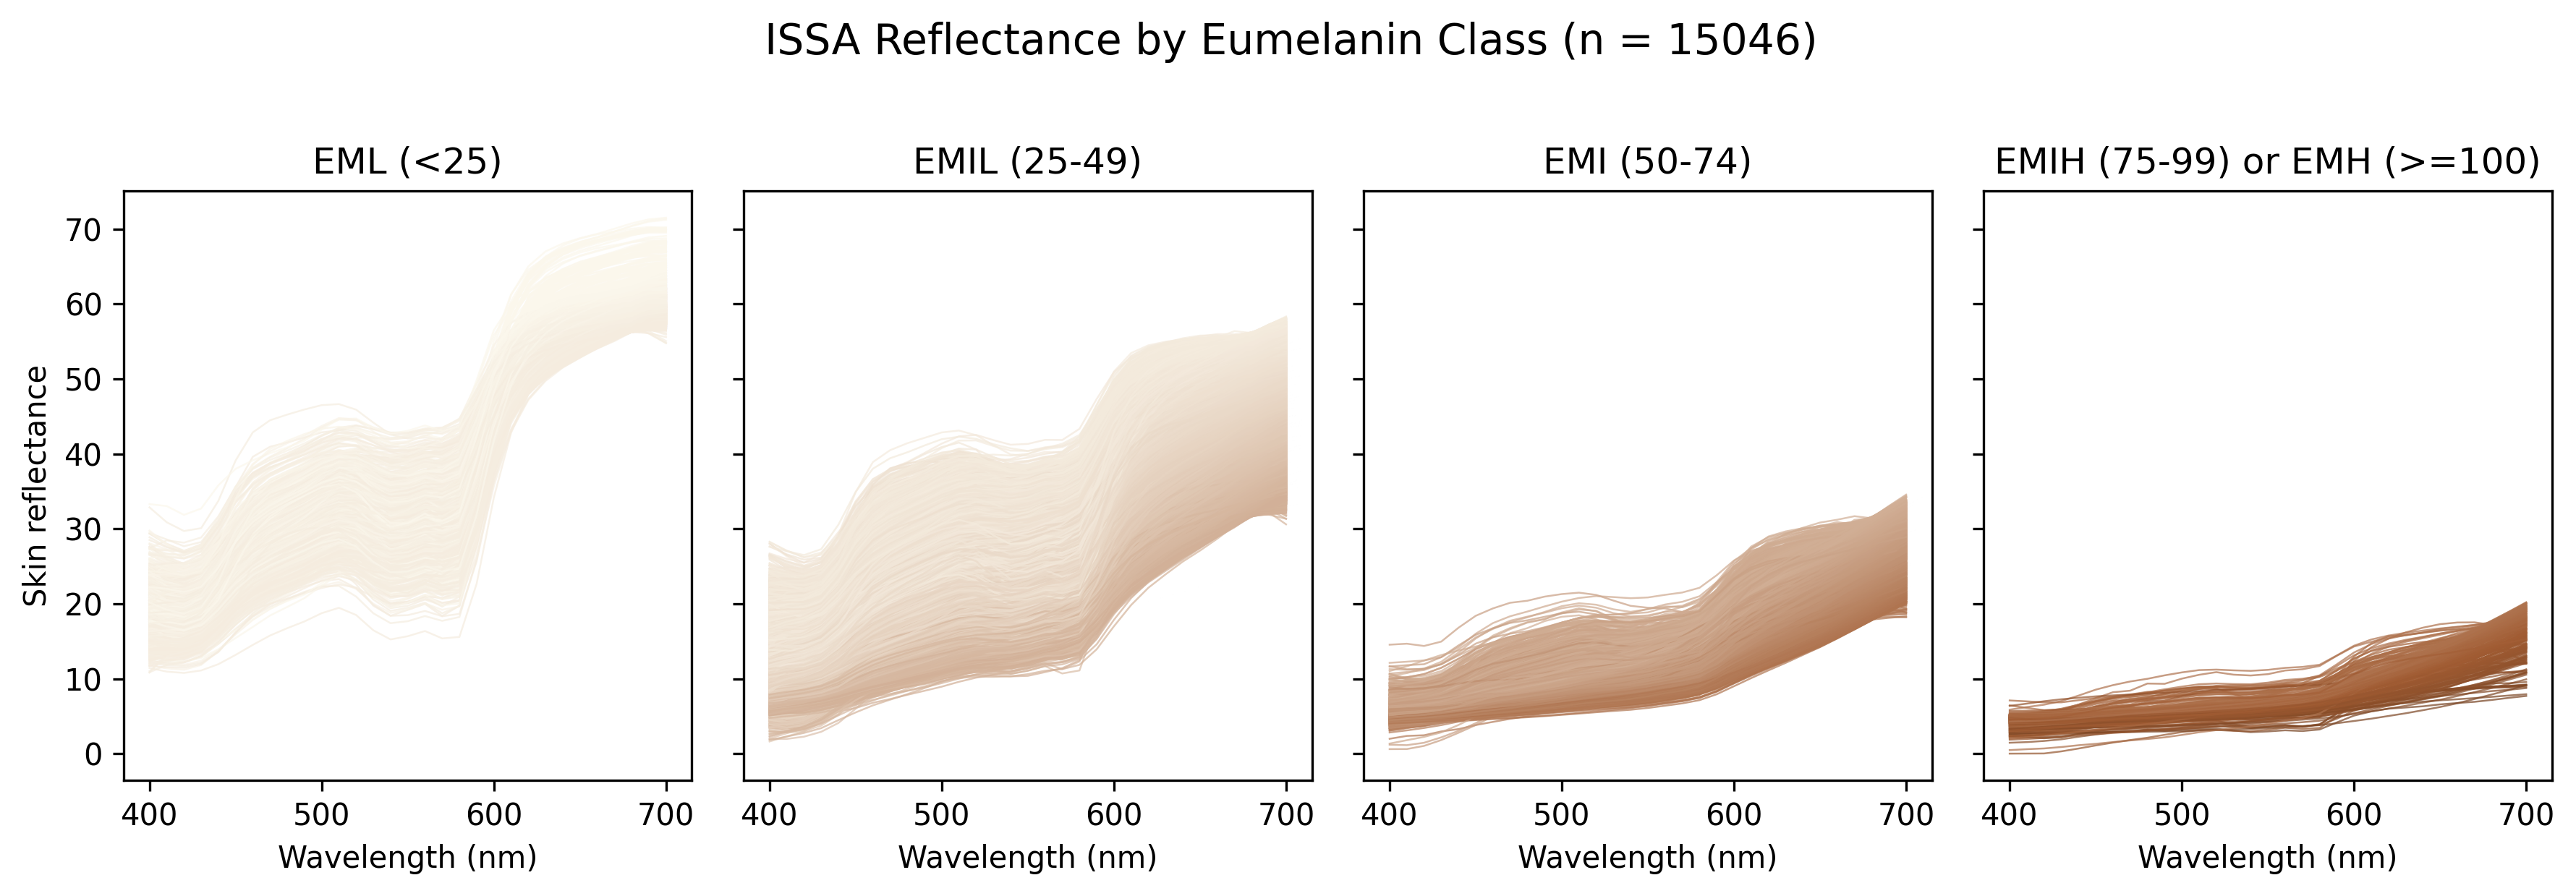

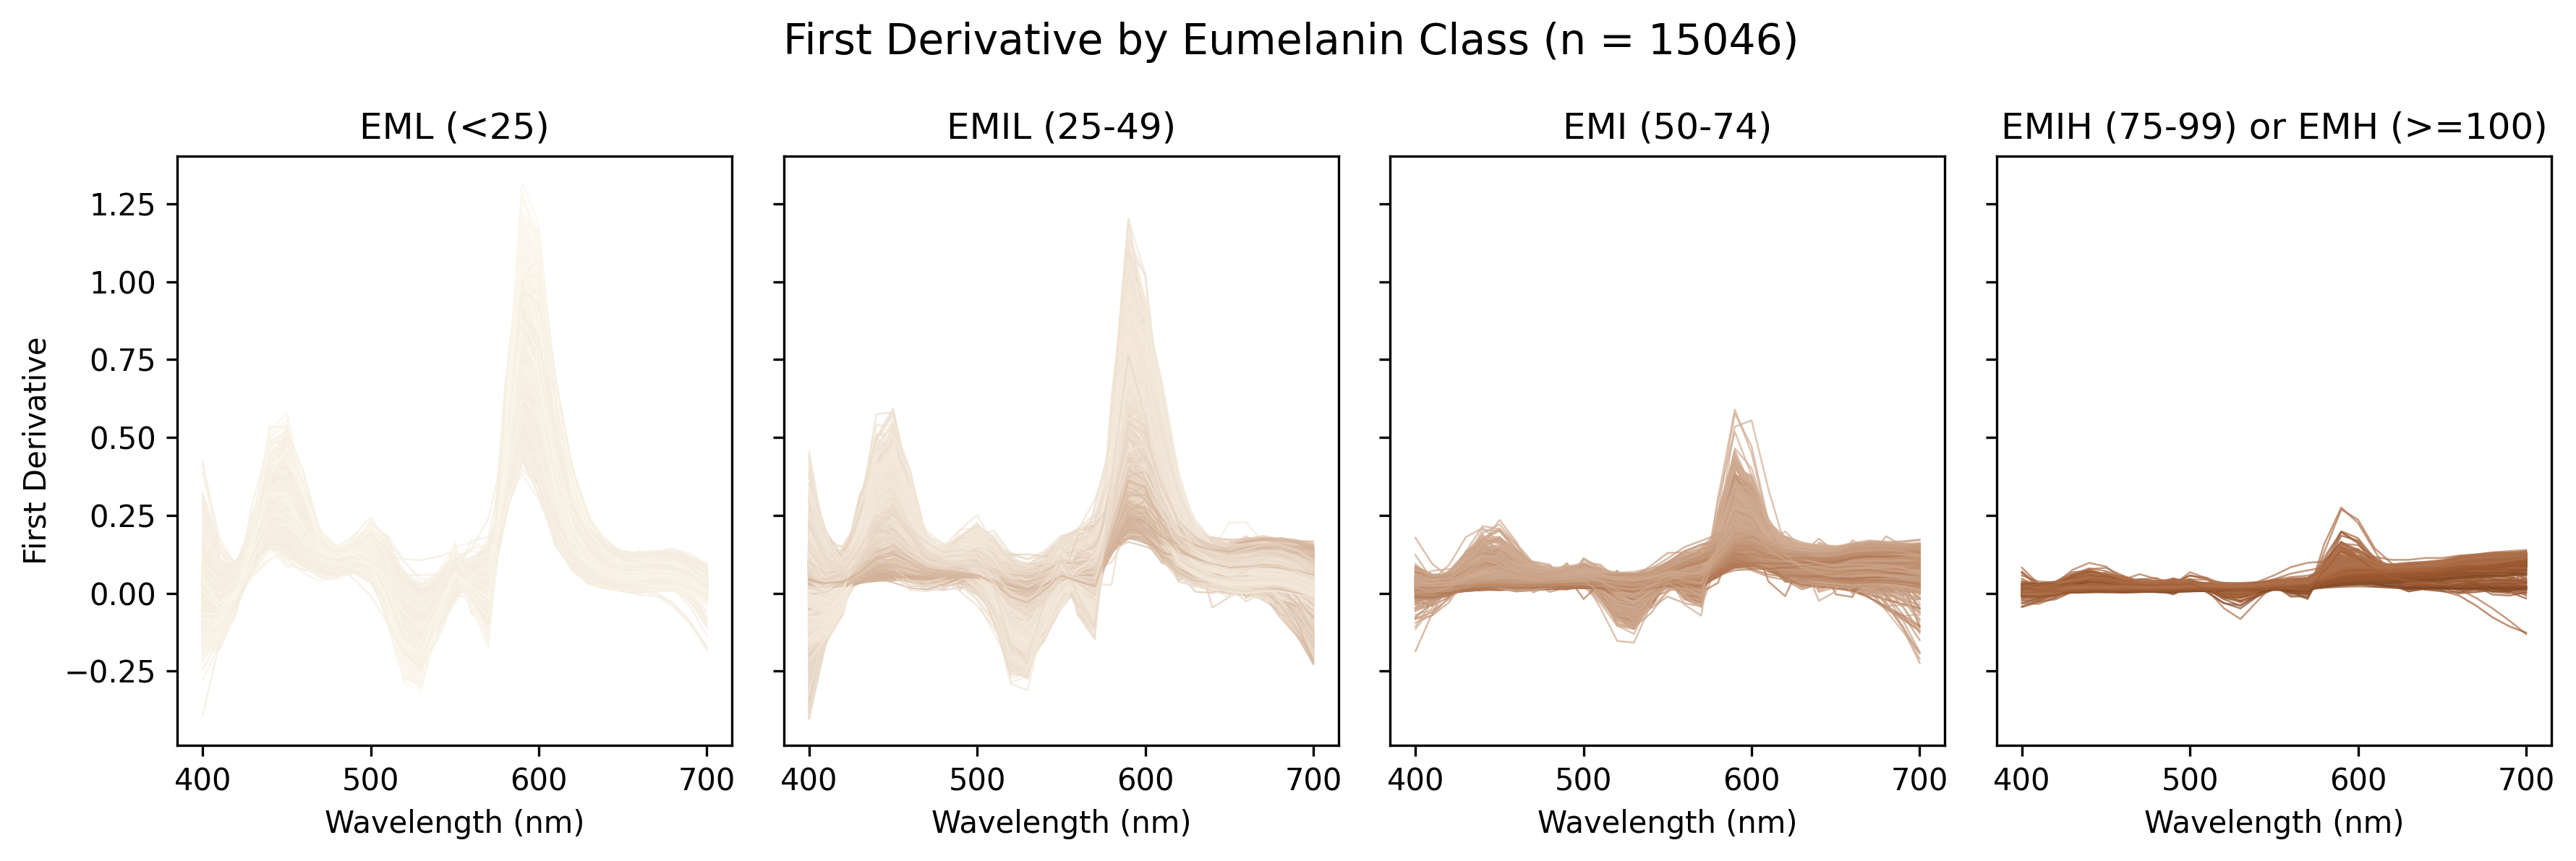

In [8]:
# Visualize the skin reflectance spectra and melanin vs erythema index side by side
fitzpatrick = ["#fbf7ec", "#a15c33", "#42230c"]
cmap = LinearSegmentedColormap.from_list("fitzpatrick", fitzpatrick)
norm = plt.Normalize(vmin=20, vmax=150)
issa_mi_clipped = np.clip(issa_mi, 20, 150)

fig, axes = plt.subplots(1, 4, figsize=(12, 4), dpi=300, sharey=True)

# Plot ISSA spectra
ax = axes[0]
eml_mask = (issa_df['Eumelanin Class'] == 'EML (<25)')
eml_indices = issa_df[eml_mask].index
for i in eml_indices:
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_spectra_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('EML (<25)')
ax.set_ylabel('Skin reflectance')
ax.set_xlabel('Wavelength (nm)')

# Plot ISSA spectra
ax = axes[1]
emil_mask = (issa_df['Eumelanin Class'] == 'EMIL (25-49)')
emil_indices = issa_df[emil_mask].index
for i in emil_indices:
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_spectra_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('EMIL (25-49)')
ax.set_xlabel('Wavelength (nm)')

# Plot ISSA spectra
ax = axes[2]
emi_mask = (issa_df['Eumelanin Class'] == 'EMI (50-74)')
emi_indices = issa_df[emi_mask].index
for i in emi_indices:
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_spectra_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('EMI (50-74)')
ax.set_xlabel('Wavelength (nm)')

# Plot ISSA spectra
ax = axes[3]
emh_mask = (issa_df['Eumelanin Class'] == 'EMIH (75-99)') | (issa_df['Eumelanin Class'] == 'EMH (>=100)')
emh_indices = issa_df[emh_mask].index
for i in emh_indices:
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_spectra_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('EMIH (75-99) or EMH (>=100)')
ax.set_xlabel('Wavelength (nm)')

plt.suptitle(f'ISSA Reflectance by Eumelanin Class (n = {issa_spectra_clean.shape[0]})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 4, figsize=(12, 4), dpi=300, sharey=True)

# Plot ISSA derivative
ax = axes[0]
for i in eml_indices:
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_drv_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('EML (<25)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('First Derivative')

# Plot ISSA derivative
ax = axes[1]
for i in emil_indices:
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_drv_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('EMIL (25-49)')
ax.set_xlabel('Wavelength (nm)')

# Plot ISSA derivative
ax = axes[2]
for i in emi_indices:
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_drv_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('EMI (50-74)')
ax.set_xlabel('Wavelength (nm)')

# Plot ISSA derivative
ax = axes[3]
for i in emh_indices:
    color = cmap(norm(issa_mi_clipped[i]))
    ax.plot(issa_wavelengths, issa_drv_clean[i, :], color=color, alpha=0.7, linewidth=0.6)
ax.set_title('EMIH (75-99) or EMH (>=100)')
ax.set_xlabel('Wavelength (nm)')

# ---- Common title ----
plt.suptitle(f'First Derivative by Eumelanin Class (n = {issa_spectra_clean.shape[0]})', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Observations

- With increasing melanin index, the magnitude of first derivatives decreases gradually. This indicates that the reflectance spectrum of darker skins is flatter than that of lighter skins.